In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 9
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8

sns.set_style("white")


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
VULN_PATH = Path("/Users/kylekimler/Projects/GCA/github_vignette_output/DALYgeneticVulnerabilities/GCAvulnerability.csv")
OT_COMBINED_PATH = Path("/Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache/combined_disease_target_df.parquet")
ADATA_PATH = Path("/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/hgca_all_lineages_v1.h5ad")
DALY_PATH = Path("/Users/kylekimler/Projects/GCA/github_vignette_output/DALYgeneticVulnerabilities/DALYtable.csv")

CELLTYPE_COL = "hgca_celltype_v1"
GENE_SYMBOL_COL = "gene_symbol"

DISEASE_ORDER = ["diarrhea", "colorectal_cancer", "crohns_disease", "ulcerative_colitis"]
DISEASE_DISPLAY = {
    "diarrhea": "Diarrhea",
    "colorectal_cancer": "Colorectal cancer",
    "crohns_disease": "Crohn's disease",
    "ulcerative_colitis": "Ulcerative colitis",
}

EXCLUDE_CELLTYPES = {"Epithelial"}

def map_disease_label(x):
    x = str(x).strip().lower()
    if x in {"crohn_disease", "crohn disease", "crohn's disease", "crohns_disease", "crohns disease"}:
        return "crohns_disease"
    if x in {"ulcerative_colitis", "ulcerative colitis"}:
        return "ulcerative_colitis"
    if x in {"colorectal_cancer", "colorectal cancer", "colon cancer", "rectal cancer"}:
        return "colorectal_cancer"
    if "diarr" in x:
        return "diarrhea"
    return x

vuln = pd.read_csv(VULN_PATH)
ot = pd.read_parquet(OT_COMBINED_PATH)
daly_tbl = pd.read_csv(DALY_PATH)

vuln["disease_label"] = vuln["gwas_disease"].map(map_disease_label)
ot["disease_label"] = ot["disease_label"].map(map_disease_label)

# use whichever DALY column actually exists
daly_source_col = "gwas_disease" if "gwas_disease" in daly_tbl.columns else "gwas_disease_id"
daly_tbl["disease_label"] = daly_tbl[daly_source_col].map(map_disease_label)

vuln = vuln.loc[~vuln["celltype"].isin(EXCLUDE_CELLTYPES)].copy()

print("vuln labels:", sorted(vuln["disease_label"].dropna().unique()))
print("ot labels:", sorted(ot["disease_label"].dropna().unique()))
print("daly labels:", sorted(daly_tbl["disease_label"].dropna().unique()))

vuln labels: ['abdominal_pain', 'colorectal_cancer', 'crohns_disease', 'diarrhea', 'inflammatory_bowel_disease', 'irritable_bowel_syndrome', 'ulcerative_colitis']
ot labels: ['colorectal_cancer', 'crohns_disease', 'diarrhea', 'ulcerative_colitis']
daly labels: ['abdominal_pain', 'colorectal_cancer', 'crohns_disease', 'diarrhea', 'inflammatory_bowel_disease', 'irritable_bowel_syndrome', 'ulcerative_colitis']


In [3]:
daly_keep = daly_tbl.loc[daly_tbl["disease_label"].isin(DISEASE_ORDER)].copy()

daly_summary = (
    daly_keep.groupby("disease_label", as_index=False)
    .agg(
        daly=("daly", "max"),
        who_cause=("who_cause", lambda x: x.dropna().iloc[0] if x.dropna().shape[0] else np.nan),
    )
)

daly_summary["daly"] = pd.to_numeric(daly_summary["daly"], errors="coerce").fillna(0)
daly_summary = daly_summary.set_index("disease_label").reindex(DISEASE_ORDER).reset_index()

assert daly_summary["daly"].notna().all(), "Missing DALY values for one or more diseases"

daly_summary["daly_weight"] = daly_summary["daly"] / daly_summary["daly"].sum()
DALY_WEIGHTS = dict(zip(daly_summary["disease_label"], daly_summary["daly_weight"]))

display(daly_summary)
print(DALY_WEIGHTS)

,disease_label,daly,who_cause,daly_weight
0,diarrhea,6.974344e+07,Diarrhoeal diseases,0.723592
1,colorectal_cancer,2.404774e+07,Colon and rectum cancers,0.249497
2,crohns_disease,1.296912e+06,Inflammatory bowel disease,0.013456
3,ulcerative_colitis,1.296912e+06,Inflammatory bowel disease,0.013456


{'diarrhea': 0.7235922359903618, 'colorectal_cancer': 0.2494966899579275, 'crohns_disease': 0.01345553702585541, 'ulcerative_colitis': 0.01345553702585541}


In [221]:
base_palette = ["#7ab66f", "#025773", "#025773"]
extra_palette = ["#f0c808", "#f27c38", "#7b4f9d", "#2e8bc0", "#f26d7d", "#8c8c8c"]

def lighten_hex(hex_color, factor=0.35):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

def build_palette(n_colors, rotation=0):
    seed = [base_palette[0], base_palette[1], lighten_hex(base_palette[1], 0.45)]
    palette = seed + extra_palette
    if len(palette) > 0:
        rotation = rotation % len(palette)
        palette = palette[rotation:] + palette[:rotation]
    return palette[:n_colors]

def style_axes_box(ax, linewidth=0.6):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)

def minmax01(x):
    x = pd.Series(x, dtype=float)
    if x.nunique(dropna=True) <= 1:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - x.min()) / (x.max() - x.min())

def zscore(x):
    x = pd.Series(x, dtype=float)
    sd = x.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - x.mean()) / sd


In [5]:
# def map_vuln_disease(x):
#     x = str(x).strip().lower()
#     if x in {"crohn_disease", "crohn disease", "crohn's disease"}:
#         return "crohn_disease"
#     if x in {"ulcerative_colitis", "ulcerative colitis"}:
#         return "ulcerative_colitis"
#     if x in {"colorectal_cancer", "colon cancer", "rectal cancer", "colorectal cancer"}:
#         return "colorectal_cancer"
#     if "diarr" in x:
#         return "diarrhea"
#     return x

# vuln["disease_label"] = vuln["gwas_disease"].map(map_vuln_disease)

# print(vuln["disease_label"].value_counts(dropna=False).head(20))
# print(sorted(set(ot["disease_label"])))


## Aggregate vulnerability to the four disease buckets


In [51]:
vuln4 = vuln.loc[vuln["disease_label"].isin(DISEASE_ORDER)].copy()

vuln_by_ct = (
    vuln4.groupby(["disease_label", "celltype"], as_index=False)
    .agg(
        vulnerability_z=("vulnerability_z", "mean"),
        vulnerability_beta=("vulnerability_beta", "mean"),
        mean_abs_z=("mean_abs_z", "mean"),
        min_fdr_p=("min_fdr_p", "min"),
        mean_neglog10_fdr=("mean_neglog10_fdr", "mean"),
        n_sig=("n_sig", "sum"),
    )
)

print(vuln_by_ct.shape)
display(vuln_by_ct.head())


(372, 8)


,disease_label,celltype,vulnerability_z,vulnerability_beta,mean_abs_z,min_fdr_p,mean_neglog10_fdr,n_sig
0,colorectal_cancer,Adipocytes,0.849254,8.804275e-09,0.849254,0.999704,0.000128,1
1,colorectal_cancer,Angiogenic_Pericytes,0.911378,1.070212e-08,0.911378,0.515713,0.287592,1
2,colorectal_cancer,Arteriolar_Endothelial,1.235841,1.441904e-08,1.235841,0.999704,0.000128,1
3,colorectal_cancer,BEST4_Colonocytes,2.688329,3.248187e-08,2.688329,0.047647,1.321968,1
4,colorectal_cancer,BEST4_Enterocytes,1.770770,2.410997e-08,1.770770,0.156528,0.805407,1


## Panel A

In [44]:
panelA

disease_label,diarrhea,colorectal_cancer,crohns_disease,ulcerative_colitis
celltype,,,,
CD4_Memory,1.385700,0.704791,4.927353,4.668378
CD4_Th17,1.612104,0.388234,4.359041,3.903611
CD8_Effector_Memory,0.464384,0.902322,4.331049,3.859110
CD8_Circulating_Effector_Memory,0.005072,1.120995,4.302451,4.210774
CD4_tTreg,2.268162,0.568382,4.044826,4.201788
...,...,...,...,...
Angiogenic_Pericytes,0.532016,0.911378,0.377815,0.247688
Muscularis_Propria_Fibroblasts,0.547019,0.182674,0.269777,0.782252
Capillary_Endothelial,0.440641,0.176072,0.582430,0.695915


In [52]:
LEVEL2_COL = "hgca_celltype_level2"

celltype_level2 = (
    adata.obs[[CELLTYPE_COL, LEVEL2_COL]]
    .dropna()
    .drop_duplicates()
    .groupby(CELLTYPE_COL)[LEVEL2_COL]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={LEVEL2_COL: "celltype_level2", CELLTYPE_COL: "cell_type"})
)

display(celltype_level2.head())

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_84181/3940511089.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CELLTYPE_COL)[LEVEL2_COL]


,cell_type,celltype_level2
0,Adipocytes,Adipocytes
1,Angiogenic Pericytes,Pericytes
2,Arteriolar Endothelial,Endothelial
3,BEST4 Colonocytes,Absorptive Epithelial
4,BEST4 Enterocytes,Absorptive Epithelial


In [53]:
vuln_by_ct = vuln_by_ct.merge(
    celltype_level2.rename(columns={"cell_type": "celltype"}),
    on="celltype",
    how="left"
)

display(vuln_by_ct.head())

,disease_label,celltype,vulnerability_z,vulnerability_beta,mean_abs_z,min_fdr_p,mean_neglog10_fdr,n_sig,celltype_level2
0,colorectal_cancer,Adipocytes,0.849254,8.804275e-09,0.849254,0.999704,0.000128,1,Adipocytes
1,colorectal_cancer,Angiogenic_Pericytes,0.911378,1.070212e-08,0.911378,0.515713,0.287592,1,NaN
2,colorectal_cancer,Arteriolar_Endothelial,1.235841,1.441904e-08,1.235841,0.999704,0.000128,1,NaN
3,colorectal_cancer,BEST4_Colonocytes,2.688329,3.248187e-08,2.688329,0.047647,1.321968,1,NaN
4,colorectal_cancer,BEST4_Enterocytes,1.770770,2.410997e-08,1.770770,0.156528,0.805407,1,NaN


In [49]:
panelA = vuln_by_ct.pivot(index="celltype", columns="disease_label", values="vulnerability_z")
panelA = panelA.reindex(columns=DISEASE_ORDER)

row_meta_v = (
    vuln_summary[["celltype", "celltype_level2", "vulnerability_mean"]]
    .drop_duplicates()
    .rename(columns={"celltype": "cell_type"})
    .copy()
)

row_meta_v["celltype_level2"] = row_meta_v["celltype_level2"].fillna("Unknown")
row_meta_v = row_meta_v.sort_values(
    ["celltype_level2", "vulnerability_mean"],
    ascending=[True, False]
)

panelA = panelA.reindex(row_meta_v["cell_type"].tolist())

fig, ax = plt.subplots(figsize=(6.2, max(7, 0.16 * panelA.shape[0])))
vmax = np.nanmax(np.abs(panelA.values))
im = ax.imshow(panelA.fillna(0).values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(panelA.shape[1]))
ax.set_xticklabels([DISEASE_DISPLAY[c] for c in panelA.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(panelA.shape[0]))
ax.set_yticklabels(panelA.index)
ax.set_title("Disease vulnerability per cell type\nGrouped by hgca_celltype_level2")

group_sizes = row_meta_v.groupby("celltype_level2").size()
boundaries = np.cumsum(group_sizes.values)[:-1]
for b in boundaries:
    ax.axhline(b - 0.5, color="white", linewidth=1.2)

style_axes_box(ax)
fig.colorbar(im, ax=ax, label="Vulnerability z")
plt.tight_layout()
plt.show()

KeyError: "['celltype_level2'] not in index"

## Disease exploredness from Open Targets summaries

In [8]:
def compute_disease_exploredness(ot_df):
    rows = []
    for disease_label, sub in ot_df.groupby("disease_label"):
        sub = sub.sort_values("association_score_max", ascending=False).copy()
        top20 = sub.head(20)
        rows.append({
            "disease_label": disease_label,
            "n_targets": sub["target_symbol"].nunique(),
            "score_sum": sub["association_score_max"].sum(),
            "score_mean": sub["association_score_max"].mean(),
            "top20_score_sum": top20["association_score_max"].sum(),
            "top20_score_mean": top20["association_score_max"].mean(),
        })

    out = pd.DataFrame(rows)
    out = out.set_index("disease_label").reindex(DISEASE_ORDER).reset_index()

    print("Exploredness table after reindex:")
    display(out)

    assert out["disease_label"].notna().all()
    assert out["n_targets"].notna().all(), "At least one disease is missing from OT after mapping"

    out["daly_weight"] = out["disease_label"].map(DALY_WEIGHTS).astype(float)
    out["exploredness_summary"] = (
        0.45 * minmax01(out["n_targets"]) +
        0.35 * minmax01(out["score_sum"]) +
        0.20 * minmax01(out["top20_score_mean"])
    )
    out["daly_x_exploredness"] = out["daly_weight"] * out["exploredness_summary"]
    return out

disease_exploredness = compute_disease_exploredness(ot)
display(disease_exploredness)

Exploredness table after reindex:


,disease_label,n_targets,score_sum,score_mean,top20_score_sum,top20_score_mean
0,diarrhea,1836,53.777929,0.029243,11.970079,0.598504
1,colorectal_cancer,13773,880.116380,0.063583,16.215615,0.810781
2,crohns_disease,6332,219.148373,0.034539,11.595577,0.579779
3,ulcerative_colitis,8825,321.799994,0.036284,11.733191,0.586660


,disease_label,n_targets,score_sum,score_mean,top20_score_sum,top20_score_mean,daly_weight,exploredness_summary,daly_x_exploredness
0,diarrhea,1836,53.777929,0.029243,11.970079,0.598504,0.723592,0.016212,0.011731
1,colorectal_cancer,13773,880.116380,0.063583,16.215615,0.810781,0.249497,1.000000,0.249497
2,crohns_disease,6332,219.148373,0.034539,11.595577,0.579779,0.013456,0.239533,0.003223
3,ulcerative_colitis,8825,321.799994,0.036284,11.733191,0.586660,0.013456,0.382950,0.005153


## Panel B

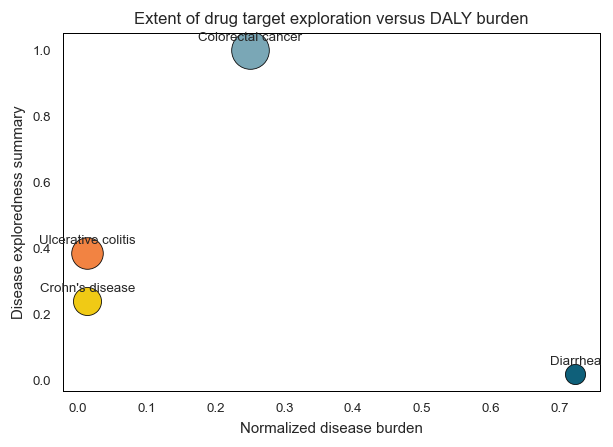

In [43]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))
plot_df = disease_exploredness.copy()
palette = build_palette(len(plot_df), rotation=1)

for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.scatter(
        r["daly_weight"],
        r["exploredness_summary"],
        s=90 + 420 * r["n_targets"] / plot_df["n_targets"].max(),
        color=palette[i],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.95,
    )
    ax.text(
        r["daly_weight"],
        r["exploredness_summary"] + 0.02,
        DISEASE_DISPLAY.get(r["disease_label"], r["disease_label"]),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xlabel("Normalized disease burden")
ax.set_ylabel("Disease exploredness summary")
ax.set_title("Extent of drug target exploration versus DALY burden")
style_axes_box(ax)
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_TargetExploredness.png", dpi=400, bbox_inches="tight")

## Load healthy atlas and compute baseline healthy program addressability


In [10]:
USE_PRECOMPUTED_BURDEN = False
PRECOMPUTED_BURDEN_PATH = Path("ot_disease_target_cache/celltype_disease_burden_df.parquet")


In [11]:
if USE_PRECOMPUTED_BURDEN and PRECOMPUTED_BURDEN_PATH.exists():
    celltype_disease_burden_df = pd.read_parquet(PRECOMPUTED_BURDEN_PATH)
    print(celltype_disease_burden_df.shape)
    display(celltype_disease_burden_df.head())
else:
    adata = sc.read_h5ad(ADATA_PATH)
    print(adata)
    assert CELLTYPE_COL in adata.obs.columns
    assert GENE_SYMBOL_COL in adata.var.columns

    gene_symbol_series = adata.var[GENE_SYMBOL_COL].astype(str)
    symbol_to_idx = {}
    for i, sym in enumerate(gene_symbol_series):
        if sym and sym != "nan":
            symbol_to_idx.setdefault(sym, []).append(i)

    ot_in_adata = ot.copy()
    ot_in_adata["target_symbol"] = ot_in_adata["target_symbol"].astype(str)
    ot_in_adata = ot_in_adata.loc[ot_in_adata["target_symbol"].isin(symbol_to_idx)].copy()

    expanded_rows = []
    for _, row in ot_in_adata.iterrows():
        for var_idx in symbol_to_idx.get(row["target_symbol"], []):
            expanded_rows.append({
                "disease_label": row["disease_label"],
                "target_id": row["target_id"],
                "target_symbol": row["target_symbol"],
                "target_name": row["target_name"],
                "association_score_max": row["association_score_max"],
                "association_score_mean": row["association_score_mean"],
                "n_source_terms": row["n_source_terms"],
                "var_idx": var_idx,
            })

    ot_feature_df = pd.DataFrame(expanded_rows)
    feature_indices = np.sort(ot_feature_df["var_idx"].astype(int).unique())
    X = adata.X[:, feature_indices]
    celltypes = adata.obs[CELLTYPE_COL].astype(str).values

    from scipy import sparse

    unique_celltypes = pd.Index(sorted(pd.unique(celltypes)))
    celltype_to_mask = {ct: (celltypes == ct) for ct in unique_celltypes}

    mean_expr_by_ct = []
    pct_expr_by_ct = []

    for ct in unique_celltypes:
        mask = celltype_to_mask[ct]
        X_ct = X[mask, :]

        if sparse.issparse(X_ct):
            mean_expr = np.asarray(X_ct.mean(axis=0)).ravel()
            pct_expr = np.asarray((X_ct > 0).mean(axis=0)).ravel()
        else:
            mean_expr = np.asarray(X_ct.mean(axis=0)).ravel()
            pct_expr = np.asarray((X_ct > 0).mean(axis=0)).ravel()

        mean_expr_by_ct.append(mean_expr)
        pct_expr_by_ct.append(pct_expr)

    mean_expr_by_ct = pd.DataFrame(np.vstack(mean_expr_by_ct), index=unique_celltypes, columns=feature_indices)
    pct_expr_by_ct = pd.DataFrame(np.vstack(pct_expr_by_ct), index=unique_celltypes, columns=feature_indices)

    feature_meta = (
        ot_feature_df[
            ["disease_label", "target_id", "target_symbol", "target_name", "association_score_max", "association_score_mean", "n_source_terms", "var_idx"]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    rows = []
    for disease_label, sub in feature_meta.groupby("disease_label"):
        var_idxs = sub["var_idx"].astype(int).tolist()
        weights = sub["association_score_max"].astype(float).values

        mean_mat = mean_expr_by_ct[var_idxs]
        pct_mat = pct_expr_by_ct[var_idxs]

        for ct in mean_mat.index:
            mean_vals = mean_mat.loc[ct].values.astype(float)
            pct_vals = pct_mat.loc[ct].values.astype(float)

            rows.append({
                "disease_label": disease_label,
                "cell_type": ct,
                "n_features": len(var_idxs),
                "n_unique_targets": sub["target_symbol"].nunique(),
                "weighted_mean_expr_burden": np.average(mean_vals, weights=weights) if len(weights) else np.nan,
                "weighted_pct_expr_burden": np.average(pct_vals, weights=weights) if len(weights) else np.nan,
                "weighted_sum_expr_burden": np.sum(mean_vals * weights),
                "weighted_sum_pct_burden": np.sum(pct_vals * weights),
            })

    celltype_disease_burden_df = pd.DataFrame(rows)
    PRECOMPUTED_BURDEN_PATH.parent.mkdir(exist_ok=True, parents=True)
    celltype_disease_burden_df.to_parquet(PRECOMPUTED_BURDEN_PATH, index=False)

print(celltype_disease_burden_df.shape)
display(celltype_disease_burden_df.head())


# EXCLUDE_CELLTYPES = {"Epithelial"}

# vuln = vuln.loc[~vuln["celltype"].isin(EXCLUDE_CELLTYPES)].copy()

celltype_disease_burden_df = celltype_disease_burden_df.loc[
    ~celltype_disease_burden_df["cell_type"].isin(EXCLUDE_CELLTYPES)
].copy()

AnnData object with n_obs × n_vars = 944502 × 35574
    obs: 'sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster', 'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2', 'qc_lineage', 'n_counts', 'n_genes', 'donor_id', 'dataset_id', 'tissue_ontology_term', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'disease_ontology_term', 'disease_ontology_term_id', 'sample_preservation_method', 'suspension_type', 'is_primary_data', 'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term', 'dissociation_protocol', 'cell_enrichment', 'sample_collection_year', 'library_id', 'library_id_repository', 'library_preparation_batch', 'library_sequencing_run', 'sample_collection_site', 'sample_collection_relative_time_point', 'cell_number_loaded', 'cell_viability_percentage', 'institute', 'author_batch_notes', 'consortia', 'study_pi', 'contact_email', 'batch_condition', 'default_emb

,disease_label,cell_type,n_features,n_unique_targets,weighted_mean_expr_burden,weighted_pct_expr_burden,weighted_sum_expr_burden,weighted_sum_pct_burden
0,colorectal_cancer,Adipocytes,12870,12840,0.759093,0.177582,652.270781,152.591750
1,colorectal_cancer,Angiogenic Pericytes,12870,12840,0.461127,0.140563,396.235555,120.782147
2,colorectal_cancer,Arteriolar Endothelial,12870,12840,0.547887,0.156622,470.786795,134.581853
3,colorectal_cancer,BEST4 Colonocytes,12870,12840,2.016385,0.226263,1732.631945,194.422436
4,colorectal_cancer,BEST4 Enterocytes,12870,12840,1.561100,0.205321,1341.416672,176.427398


## Summarize healthy program addressability


In [12]:
burden = celltype_disease_burden_df.copy()
burden = burden.loc[burden["disease_label"].isin(DISEASE_ORDER)].copy()
burden["daly_weight"] = burden["disease_label"].map(DALY_WEIGHTS).astype(float)

summary_rows = []
for cell_type, sub in burden.groupby("cell_type"):
    val = sub["weighted_mean_expr_burden"].astype(float)
    w = sub["daly_weight"].astype(float)
    summary_rows.append({
        "cell_type": cell_type,
        "addressability_mean": np.average(val, weights=w) if len(sub) else np.nan,
        "addressability_max": val.max() if len(sub) else np.nan,
        "addressability_pct_mean": np.average(sub["weighted_pct_expr_burden"].astype(float), weights=w) if len(sub) else np.nan,
    })



,cell_type,addressability_mean,addressability_max,addressability_pct_mean,addressability_mean_z,addressability_max_z,addressability_breadth
39,Foveolar Cells,2.915114,3.068903,0.228995,3.321248,2.760967,4
80,Secretory Progenitors,2.217812,2.409555,0.251578,2.282870,1.896311,4
5,Brunners Gland Cells,2.130417,2.625956,0.258734,2.152726,2.180095,4
25,Crypt Top Colonocytes,2.125321,2.208463,0.218484,2.145138,1.632603,4
61,Microfold Cells (M Cells),2.024203,2.562556,0.250313,1.994559,2.096954,4
51,Lower Villus Enterocytes,2.000662,2.438693,0.257746,1.959504,1.934523,4
33,Enterocyte Progenitors,1.993017,2.554107,0.256472,1.948120,2.085873,4
62,Mid Crypt Colonocytes,1.967720,2.521099,0.247124,1.910449,2.042588,4
22,Colonocyte Progenitors,1.946282,2.705902,0.262421,1.878525,2.284935,4
84,Transiently Amplifying Cells (TA),1.878875,2.426168,0.245194,1.778146,1.918097,4


In [73]:
addressability = pd.DataFrame(summary_rows)
addressability["addressability_mean_z"] = zscore(addressability["addressability_mean"])
addressability["addressability_max_z"] = zscore(addressability["addressability_max"])

med_by_disease = burden.groupby("disease_label")["weighted_mean_expr_burden"].median().to_dict()
tmp = burden.copy()
tmp["above_median"] = tmp.apply(lambda r: r["weighted_mean_expr_burden"] > med_by_disease[r["disease_label"]], axis=1)
breadth = tmp.groupby("cell_type", as_index=False)["above_median"].sum().rename(columns={"above_median": "addressability_breadth"})
addressability = addressability.merge(breadth, on="cell_type", how="left")

display(addressability.sort_values("addressability_mean", ascending=False).head(20))


,cell_type,addressability_mean,addressability_max,addressability_pct_mean,addressability_mean_z,addressability_max_z,addressability_breadth
39,Foveolar Cells,2.915114,3.068903,0.228995,3.321248,2.760967,4
80,Secretory Progenitors,2.217812,2.409555,0.251578,2.282870,1.896311,4
5,Brunners Gland Cells,2.130417,2.625956,0.258734,2.152726,2.180095,4
25,Crypt Top Colonocytes,2.125321,2.208463,0.218484,2.145138,1.632603,4
61,Microfold Cells (M Cells),2.024203,2.562556,0.250313,1.994559,2.096954,4
51,Lower Villus Enterocytes,2.000662,2.438693,0.257746,1.959504,1.934523,4
33,Enterocyte Progenitors,1.993017,2.554107,0.256472,1.948120,2.085873,4
62,Mid Crypt Colonocytes,1.967720,2.521099,0.247124,1.910449,2.042588,4
22,Colonocyte Progenitors,1.946282,2.705902,0.262421,1.878525,2.284935,4
84,Transiently Amplifying Cells (TA),1.878875,2.426168,0.245194,1.778146,1.918097,4


## Panel C


In [74]:
addressability = addressability.merge(
    celltype_level2,
    on="cell_type",
    how="left"
)

display(addressability.head())




,cell_type,addressability_mean,addressability_max,addressability_pct_mean,addressability_mean_z,addressability_max_z,addressability_breadth,celltype_level2
0,Adipocytes,0.468019,0.759093,0.117725,-0.322811,-0.268071,4,Adipocytes
1,Angiogenic Pericytes,0.250413,0.461127,0.093913,-0.646856,-0.658818,0,Pericytes
2,Arteriolar Endothelial,0.299967,0.547887,0.105462,-0.573063,-0.545042,0,Endothelial
3,BEST4 Colonocytes,1.643366,2.016385,0.218814,1.427441,1.380716,4,Absorptive Epithelial
4,BEST4 Enterocytes,1.318868,1.561100,0.207926,0.944219,0.783665,4,Absorptive Epithelial


In [89]:
panelC = burden.pivot(index="cell_type", columns="disease_label", values="weighted_mean_expr_burden")
panelC = panelC.reindex(columns=DISEASE_ORDER)

row_meta = (
    addressability[["cell_type", "celltype_level2", "addressability_mean"]]
    .drop_duplicates()
    .copy()
)

row_meta["celltype_level2"] = row_meta["celltype_level2"].astype(str)
row_meta["celltype_level2"] = row_meta["celltype_level2"].replace(
    {"nan": "Unknown", "None": "Unknown", "<NA>": "Unknown"}
)

row_meta = row_meta.sort_values(
    ["celltype_level2", "addressability_mean"],
    ascending=[True, False]
)

ordered_celltypes = row_meta["cell_type"].tolist()
panelC = panelC.reindex(ordered_celltypes)
ordered_celltypes = row_meta["cell_type"].tolist()
panelC = panelC.reindex(ordered_celltypes)



In [155]:
panelC.index = panelC.index.str.replace("\n", " ", regex=False)
panelC.index = panelC.index.str.replace("Mesenchymal Lymphoid Tissue Organizer Cells", " ", regex=False)

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_84181/1385079463.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


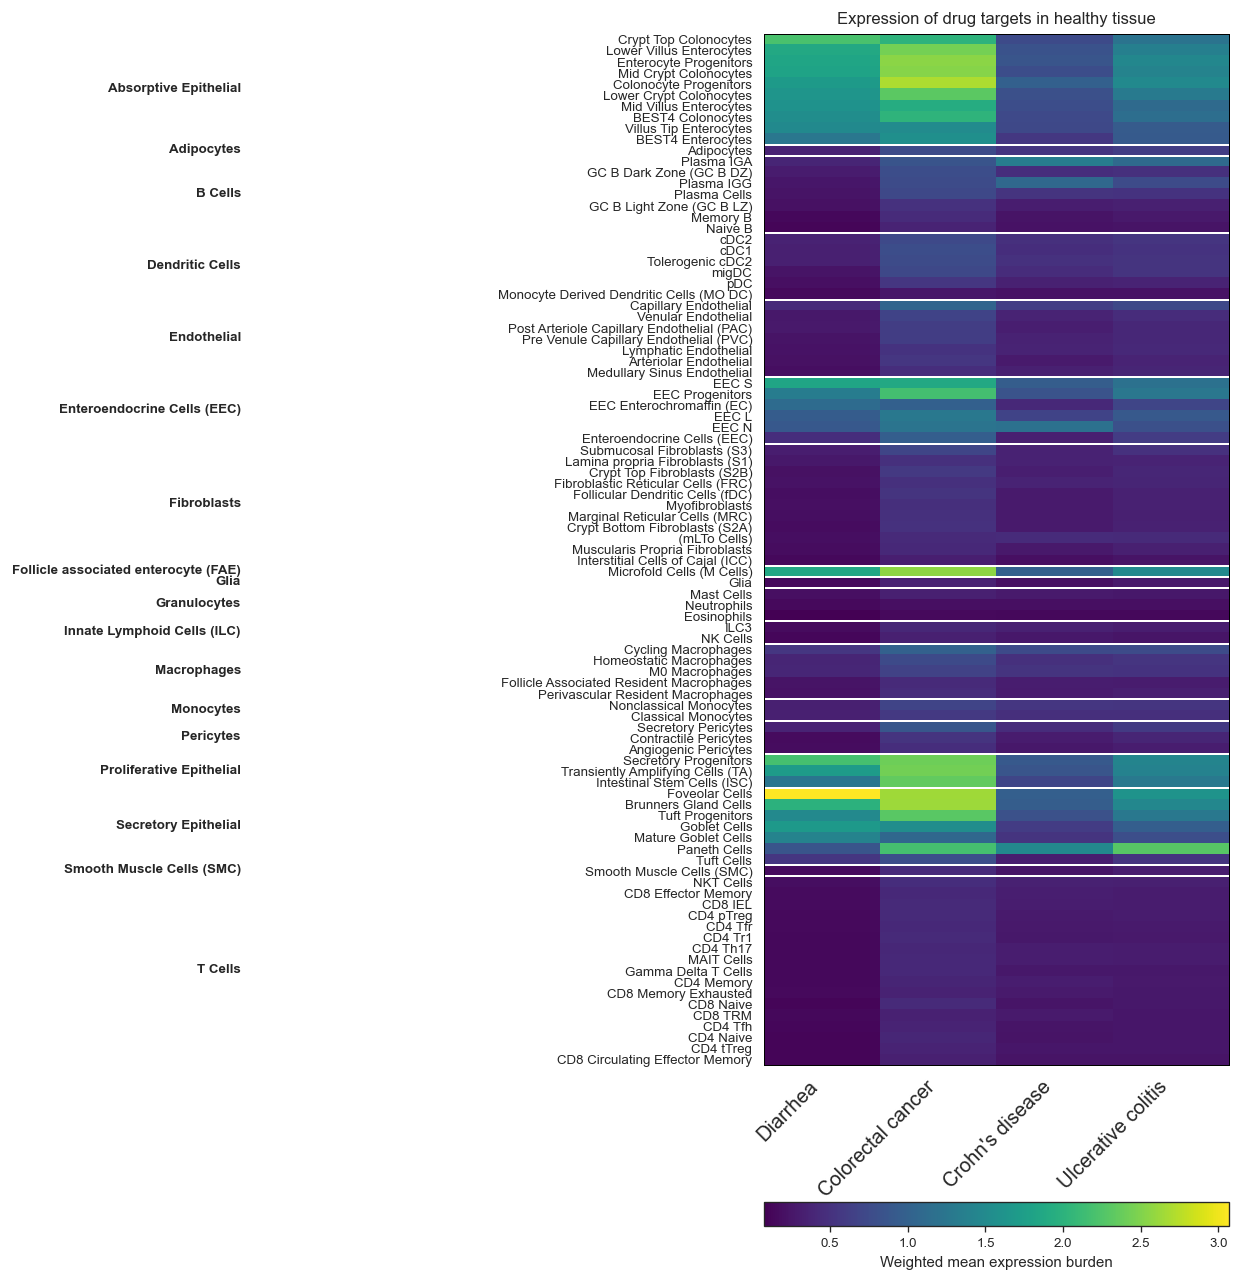

In [156]:
fig, ax = plt.subplots(figsize=(5, 0.16 * panelC.shape[0]))

im = ax.imshow(
    panelC.fillna(0).values,
    aspect="auto",
    cmap="viridis"
)

ax.set_xticks(np.arange(panelC.shape[1]))
ax.set_xticklabels([DISEASE_DISPLAY[c] for c in panelC.columns], rotation=45, ha="right")
ax.tick_params(axis="x", labelsize=12)
ax.set_yticks(np.arange(panelC.shape[0]))
ax.set_yticklabels(panelC.index)

ax.set_title("Expression of drug targets in healthy tissue")

group_sizes = row_meta.groupby("celltype_level2").size()
boundaries = np.cumsum(group_sizes.values)[:-1]
for b in boundaries:
    ax.axhline(b - 0.5, color="white", linewidth=1.2)

group_centers = np.cumsum(group_sizes.values) - group_sizes.values / 2 - 0.5
for center, label in zip(group_centers, group_sizes.index):
    ax.text(
        -5,
        center-0.1,
        label,
        va="center",
        ha="right",
        fontsize=8,
        fontweight="bold"
    )

style_axes_box(ax)

cbar = fig.colorbar(im, ax=ax, pad=0.1, location='bottom')
cbar.set_label("Weighted mean expression burden")

plt.tight_layout()
plt.show()


fig.savefig(f"{OUT_DIR}_Healthy_Target_Expression.png", dpi=400, bbox_inches="tight")

## Merge vulnerability and addressability


In [14]:
print("vuln_by_ct disease labels:")
print(sorted(vuln_by_ct["disease_label"].dropna().unique()))

print("\nburden disease labels:")
print(sorted(burden["disease_label"].dropna().unique()))

print("\nShared labels:")
print(sorted(set(vuln_by_ct["disease_label"]).intersection(set(burden["disease_label"]))))

vuln_by_ct disease labels:
['colorectal_cancer', 'crohns_disease', 'diarrhea', 'ulcerative_colitis']

burden disease labels:
['colorectal_cancer', 'crohns_disease', 'diarrhea', 'ulcerative_colitis']

Shared labels:
['colorectal_cancer', 'crohns_disease', 'diarrhea', 'ulcerative_colitis']


In [186]:
vuln_summary = vuln_by_ct.copy()
vuln_summary["daly_weight"] = vuln_summary["disease_label"].map(DALY_WEIGHTS).astype(float)

vuln_summary = (
    vuln_summary.groupby("celltype", as_index=False)
    .apply(lambda g: pd.Series({
        "vulnerability_mean": np.average(g["vulnerability_z"].astype(float), weights=g["daly_weight"].astype(float)),
        "vulnerability_max": g["vulnerability_z"].max(),
        "vulnerability_sig_sum": g["n_sig"].sum(),
        "vulnerability_mean_neglog10_fdr": np.average(g["mean_neglog10_fdr"].astype(float), weights=g["daly_weight"].astype(float)),
    }))
    .reset_index(drop=True)
)

vuln_summary["vulnerability_mean_z"] = zscore(vuln_summary["vulnerability_mean"])
vuln_summary["vulnerability_max_z"] = zscore(vuln_summary["vulnerability_max"])

celltype_summary = vuln_summary.merge(addressability, left_on="celltype", right_on="cell_type", how="inner")
celltype_summary["gap_score"] = celltype_summary["vulnerability_mean_z"] - celltype_summary["addressability_mean_z"]
celltype_summary["opportunity_score"] = (
    0.55 * minmax01(celltype_summary["vulnerability_mean_z"]) +
    0.25 * (1 - minmax01(celltype_summary["addressability_mean_z"])) +
    0.20 * minmax01(celltype_summary["vulnerability_sig_sum"])
)

# print(celltype_summary.shape)
# display(celltype_summary.sort_values("gap_score", ascending=False).head(20))


# disease stratified merge
addressability_by_ct_disease = burden.copy()[[
    "disease_label",
    "cell_type",
    "weighted_mean_expr_burden",
    "weighted_pct_expr_burden",
    "weighted_sum_expr_burden",
    "weighted_sum_pct_burden",
]].rename(columns={
    "cell_type": "celltype",
    "weighted_mean_expr_burden": "addressability_mean",
    "weighted_pct_expr_burden": "addressability_pct_mean",
    "weighted_sum_expr_burden": "addressability_sum",
    "weighted_sum_pct_burden": "addressability_pct_sum",
})

import re

def clean_key(s):
    s = str(s).strip().lower()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", "_", s)
    return s

addressability_by_ct_disease_clean = addressability_by_ct_disease.copy()

vuln_by_ct["celltype_clean"] = vuln_by_ct["celltype"].map(clean_key)
addressability_by_ct_disease_clean["celltype_clean"] = addressability_by_ct_disease_clean["celltype"].map(clean_key)

celltype_disease_summary = vuln_by_ct.merge(
    addressability_by_ct_disease_clean,
    on=["disease_label", "celltype_clean"],
    how="inner"
)

celltype_disease_summary['celltype'] = celltype_disease_summary['celltype_y']


celltype_disease_summary["vulnerability_z_disease"] = (
    celltype_disease_summary.groupby("disease_label")["vulnerability_z"]
    .transform(zscore)
)

celltype_disease_summary["addressability_mean_z_disease"] = (
    celltype_disease_summary.groupby("disease_label")["addressability_mean"]
    .transform(zscore)
)

celltype_disease_summary["gap_score"] = (
    celltype_disease_summary["vulnerability_z_disease"]
    - celltype_disease_summary["addressability_mean_z_disease"]
)

celltype_disease_summary["opportunity_score"] = (
    0.6 * minmax01(celltype_disease_summary["vulnerability_z_disease"]) +
    0.4 * (1 - minmax01(celltype_disease_summary["addressability_mean_z_disease"]))
)

print(celltype_disease_summary.shape)
display(celltype_disease_summary.head())

(372, 20)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_84181/713275272.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,disease_label,celltype_x,vulnerability_z,vulnerability_beta,mean_abs_z,min_fdr_p,mean_neglog10_fdr,n_sig,celltype_level2,celltype_clean,celltype_y,addressability_mean,addressability_pct_mean,addressability_sum,addressability_pct_sum,celltype,vulnerability_z_disease,addressability_mean_z_disease,gap_score,opportunity_score
0,colorectal_cancer,Adipocytes,0.849254,8.804275e-09,0.849254,0.999704,0.000128,1,Adipocytes,adipocytes,Adipocytes,0.759093,0.177582,652.270781,152.591750,Adipocytes,-0.640680,-0.243918,-0.396762,0.444577
1,colorectal_cancer,Angiogenic_Pericytes,0.911378,1.070212e-08,0.911378,0.515713,0.287592,1,NaN,angiogenic_pericytes,Angiogenic Pericytes,0.461127,0.140563,396.235555,120.782147,Angiogenic Pericytes,-0.566181,-0.645590,0.079408,0.485499
2,colorectal_cancer,Arteriolar_Endothelial,1.235841,1.441904e-08,1.235841,0.999704,0.000128,1,NaN,arteriolar_endothelial,Arteriolar Endothelial,0.547887,0.156622,470.786795,134.581853,Arteriolar Endothelial,-0.177091,-0.528633,0.351541,0.524259
3,colorectal_cancer,BEST4_Colonocytes,2.688329,3.248187e-08,2.688329,0.047647,1.321968,1,NaN,best4_colonocytes,BEST4 Colonocytes,2.016385,0.226263,1732.631945,194.422436,BEST4 Colonocytes,1.564710,1.450970,0.113740,0.582743
4,colorectal_cancer,BEST4_Enterocytes,1.770770,2.410997e-08,1.770770,0.156528,0.805407,1,NaN,best4_enterocytes,BEST4 Enterocytes,1.561100,0.205321,1341.416672,176.427398,BEST4 Enterocytes,0.464388,0.837226,-0.372838,0.495490


## Panel D

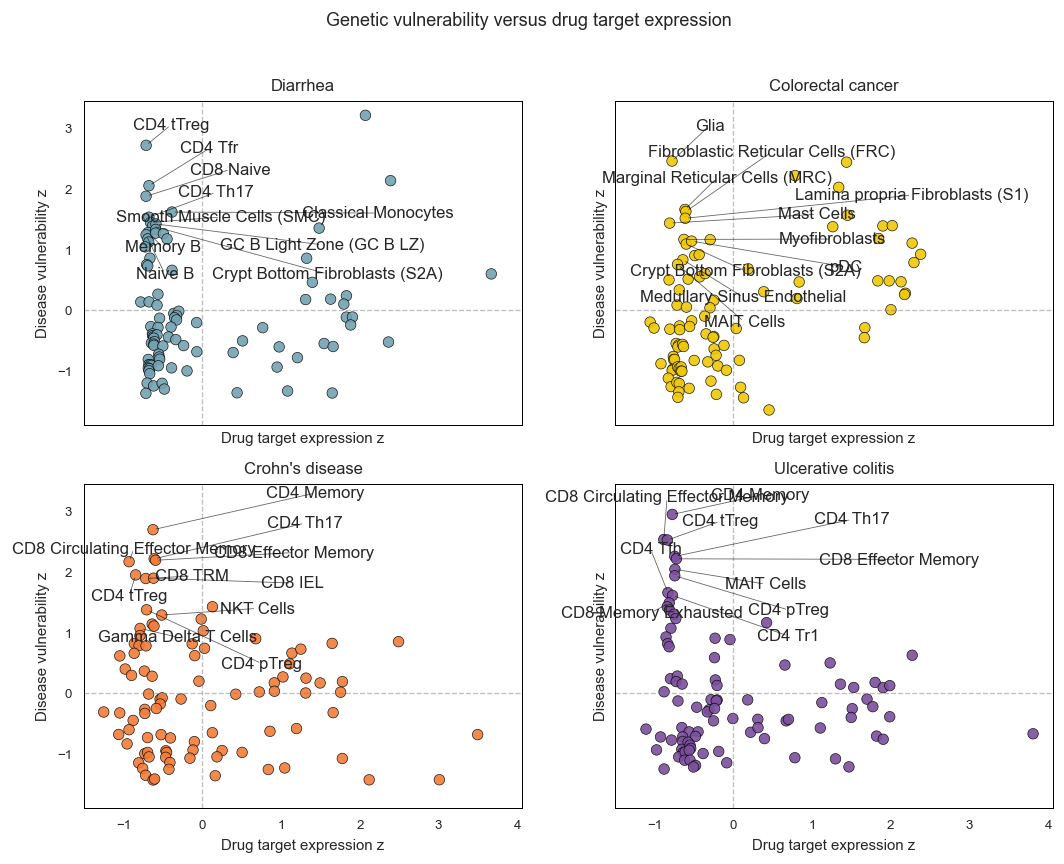

In [187]:

from adjustText import adjust_text


from adjustText import adjust_text

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
axes = axes.ravel()
palette = build_palette(len(DISEASE_ORDER), rotation=2)

for i, disease_label in enumerate(DISEASE_ORDER):
    ax = axes[i]
    sub = celltype_disease_summary.loc[
        celltype_disease_summary["disease_label"] == disease_label
    ].copy().sort_values("gap_score", ascending=False)

    ax.scatter(
        sub["addressability_mean_z_disease"],
        sub["vulnerability_z_disease"],
        s=40 + 16 * minmax01(sub["n_sig"]),
        color=palette[i],
        edgecolor="black",
        linewidth=0.4,
        alpha=0.9,
    )

    texts = []
    top_labels = sub.head(10)
    for _, r in top_labels.iterrows():
        texts.append(
            ax.text(
                r["addressability_mean_z_disease"],
                r["vulnerability_z_disease"],
                r["celltype"],
                fontsize=10,
                ha="center",
                va="center",
            )
        )

    adjust_text(
        texts,
        ax=ax,
        expand_points=(1.2, 1.4),
        expand_text=(1.2, 1.4),
        force_points=0.6,
        force_text=0.8,
        arrowprops=dict(arrowstyle="-", lw=0.5, color="black", alpha=0.6),
    )

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(DISEASE_DISPLAY[disease_label])
    ax.set_xlabel("Drug target expression z")
    ax.set_ylabel("Disease vulnerability z")
    style_axes_box(ax)

fig.suptitle("Genetic vulnerability versus drug target expression", y=1.02)
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_Expression_x_Vulnerability_per_disease.png", dpi=400, bbox_inches="tight")

## Panel E

In [161]:
print(disease_label)
print(
    celltype_disease_summary.loc[
        celltype_disease_summary["disease_label"] == disease_label,
        ["celltype", "gap_score"]
    ].sort_values("gap_score", ascending=False).head(50)
)

ulcerative_colitis
          celltype  gap_score
32            Glia   2.615388
31     Eosinophils   1.113886
38           migDC   0.755283
33            ILC3   0.613677
35     Neutrophils   0.229682
37            cDC2  -0.800372
34  Myofibroblasts  -0.815597
36            cDC1  -0.911682
39             pDC  -0.977176
30      Adipocytes  -1.823089


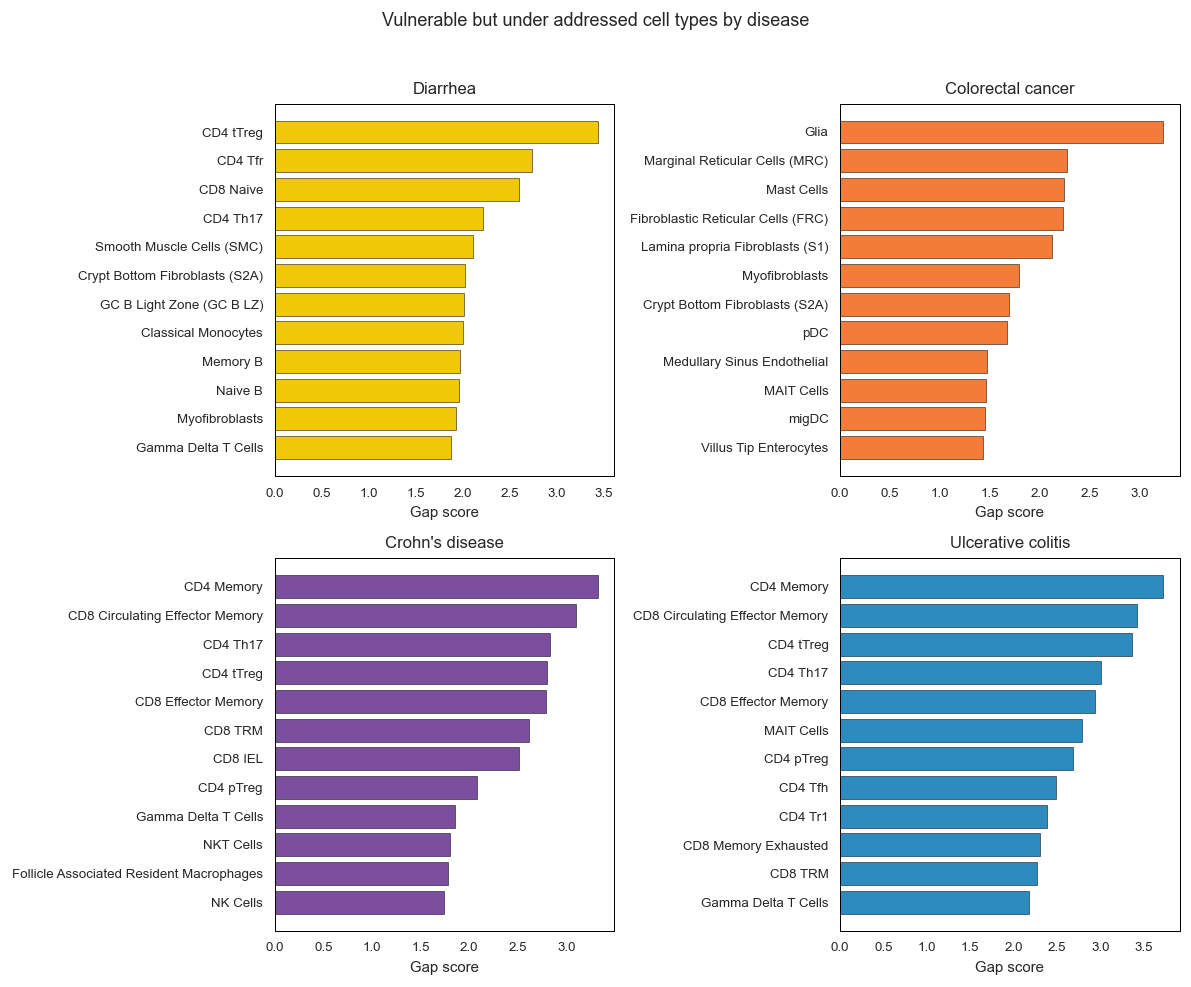

In [188]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
palette = build_palette(len(DISEASE_ORDER), rotation=3)

for i, disease_label in enumerate(DISEASE_ORDER):
    ax = axes[i]
    sub = (
        celltype_disease_summary.loc[celltype_disease_summary["disease_label"] == disease_label]
        .sort_values("gap_score", ascending=False)
        .head(12)
        .iloc[::-1]
        .copy()
    )

    ax.barh(
        sub["celltype"],
        sub["gap_score"],
        color=palette[i],
        edgecolor="black",
        linewidth=0.3,
    )

    ax.set_title(DISEASE_DISPLAY[disease_label])
    ax.set_xlabel("Gap score")
    ax.set_ylabel("")
    style_axes_box(ax)

fig.suptitle("Vulnerable but under addressed cell types by disease", y=1.02)
plt.tight_layout()
plt.show()


fig.savefig(f"{OUT_DIR}_vulnerable_but_not_addressed_gap.png", dpi=400, bbox_inches="tight")

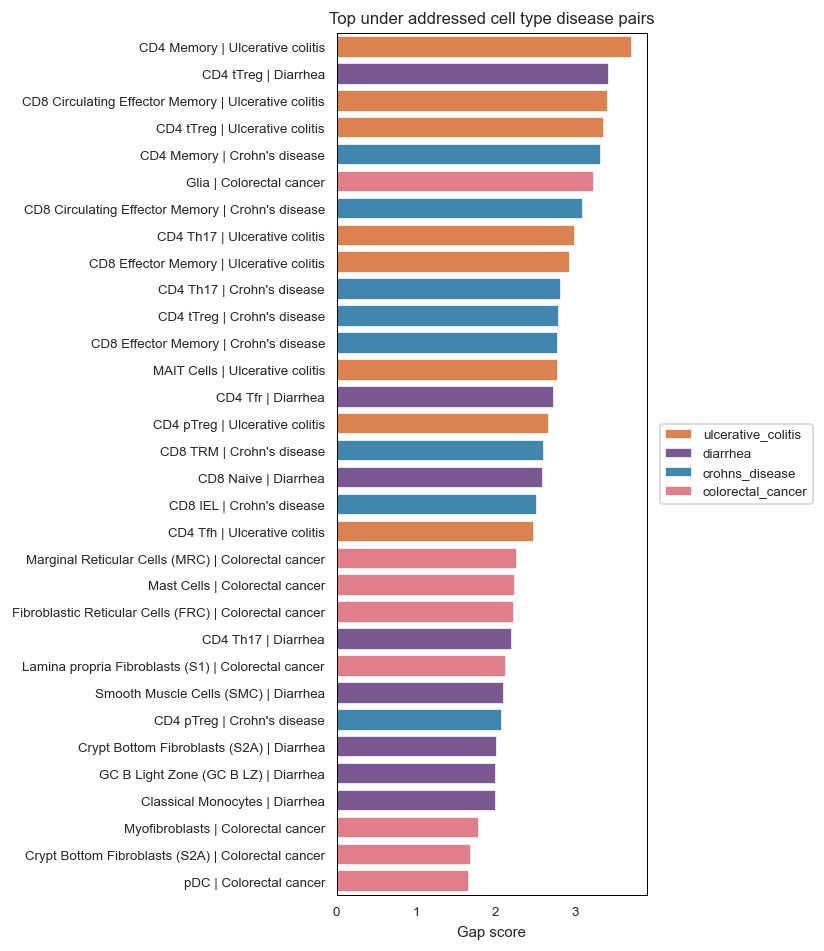

In [189]:
panelE_long = (
    celltype_disease_summary
    .sort_values(["disease_label", "gap_score"], ascending=[True, False])
    .groupby("disease_label", as_index=False, group_keys=False)
    .head(8)
    .copy()
)

panelE_long["label"] = panelE_long["celltype"] + " | " + panelE_long["disease_label"].map(DISEASE_DISPLAY)

fig, ax = plt.subplots(figsize=(7, 8))
sns.barplot(
    data=panelE_long.sort_values("gap_score", ascending=False),
    y="label",
    x="gap_score",
    hue="disease_label",
    dodge=False,
    palette=build_palette(len(DISEASE_ORDER), rotation=4),
    ax=ax,
)

ax.set_xlabel("Gap score")
ax.set_ylabel("")
ax.set_title("Top under addressed cell type disease pairs")
ax.legend(title="", loc="center left", bbox_to_anchor=(1.02, 0.5))
style_axes_box(ax)
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_vulnerable_but_not_addressed_gap_stacked.png", dpi=400, bbox_inches="tight")

## Panel F scaffold

This part scaffolds the next Open Targets pass.

Goal:
- take the top under addressed cell types from panel E
- identify their leading disease linked genes
- query target known drugs and disease history
- summarize non gut disease reuse and repurposing opportunities

For now this section extracts leading genes per top cell type from the current healthy program burden tables.


In [191]:
TOP_CT_FOR_REPURPOSING = panelE_long["celltype"].drop_duplicates().tail(8).tolist()

if "adata" in globals():
    rows = []
    from scipy import sparse

    ot_sub = ot.copy()
    ot_sub["target_symbol"] = ot_sub["target_symbol"].astype(str)

    gene_symbols = adata.var[GENE_SYMBOL_COL].astype(str).values
    celltypes = adata.obs[CELLTYPE_COL].astype(str).values

    for ct in TOP_CT_FOR_REPURPOSING:
        ct_mask = celltypes == ct
        for disease_label, sub in ot_sub.groupby("disease_label"):
            for _, r in sub.iterrows():
                idxs = np.where(gene_symbols == r["target_symbol"])[0]
                if len(idxs) == 0:
                    continue

                X_ct = adata.X[ct_mask][:, idxs]
                if sparse.issparse(X_ct):
                    expr = float(np.asarray(X_ct.mean(axis=0)).ravel().mean())
                else:
                    expr = float(np.asarray(X_ct).mean())

                rows.append({
                    "cell_type": ct,
                    "disease_label": disease_label,
                    "target_symbol": r["target_symbol"],
                    "target_id": r["target_id"],
                    "association_score_max": r["association_score_max"],
                    "target_contribution": expr * r["association_score_max"],
                })

    target_contrib = pd.DataFrame(rows).sort_values("target_contribution", ascending=False)
    display(target_contrib.head(30))
else:
    print("Load adata in this notebook to extract target contributions for repurposing follow up")

,cell_type,disease_label,target_symbol,target_id,association_score_max,target_contribution
101,CD4 pTreg,colorectal_cancer,B2M,ENSG00000166710,0.559605,37.792527
85358,Smooth Muscle Cells (SMC),colorectal_cancer,MT-CO1,ENSG00000198804,0.503024,34.194249
28474,CD4 Tfr,colorectal_cancer,B2M,ENSG00000166710,0.559605,30.959605
170339,MAIT Cells,colorectal_cancer,B2M,ENSG00000166710,0.559605,28.249225
142104,Classical Monocytes,colorectal_cancer,MT-CO1,ENSG00000198804,0.503024,27.053300
141966,Classical Monocytes,colorectal_cancer,B2M,ENSG00000166710,0.559605,25.733908
114045,GC B Light Zone (GC B LZ),colorectal_cancer,CD74,ENSG00000019582,0.395060,23.497449
29626,CD4 Tfr,colorectal_cancer,MALAT1,ENSG00000251562,0.118604,23.435378
113731,GC B Light Zone (GC B LZ),colorectal_cancer,MT-CO1,ENSG00000198804,0.503024,23.339763
199864,CD4 Tfh,colorectal_cancer,MALAT1,ENSG00000251562,0.118604,22.843522


In [192]:
top_rep = (
    celltype_disease_summary
    .sort_values("gap_score", ascending=False)
    .groupby("disease_label", as_index=False, group_keys=False)
    .head(4)
    .copy()
)

display(top_rep[["disease_label", "celltype", "gap_score"]])

TOP_CT_FOR_REPURPOSING = top_rep["celltype"].drop_duplicates().tolist()
print(TOP_CT_FOR_REPURPOSING)

,disease_label,celltype,gap_score
285,ulcerative_colitis,CD4 Memory,3.723412
199,diarrhea,CD4 tTreg,3.434978
293,ulcerative_colitis,CD8 Circulating Effector Memory,3.417829
292,ulcerative_colitis,CD4 tTreg,3.363473
99,crohns_disease,CD4 Memory,3.324555
43,colorectal_cancer,Glia,3.239352
107,crohns_disease,CD8 Circulating Effector Memory,3.099872
289,ulcerative_colitis,CD4 Th17,3.000737
103,crohns_disease,CD4 Th17,2.828743
106,crohns_disease,CD4 tTreg,2.798354


['CD4 Memory', 'CD4 tTreg', 'CD8 Circulating Effector Memory', 'Glia', 'CD4 Th17', 'CD4 Tfr', 'CD8 Naive', 'Marginal Reticular Cells (MRC)', 'Mast Cells', 'Fibroblastic Reticular Cells (FRC)']


In [193]:
top_rep_pairs = (
    celltype_disease_summary
    .sort_values("gap_score", ascending=False)
    .groupby("disease_label", as_index=False, group_keys=False)
    .head(4)
    .copy()
)

display(top_rep_pairs[["disease_label", "celltype", "gap_score"]])

,disease_label,celltype,gap_score
285,ulcerative_colitis,CD4 Memory,3.723412
199,diarrhea,CD4 tTreg,3.434978
293,ulcerative_colitis,CD8 Circulating Effector Memory,3.417829
292,ulcerative_colitis,CD4 tTreg,3.363473
99,crohns_disease,CD4 Memory,3.324555
43,colorectal_cancer,Glia,3.239352
107,crohns_disease,CD8 Circulating Effector Memory,3.099872
289,ulcerative_colitis,CD4 Th17,3.000737
103,crohns_disease,CD4 Th17,2.828743
106,crohns_disease,CD4 tTreg,2.798354


In [194]:
from scipy import sparse

rows = []
gene_symbols = adata.var[GENE_SYMBOL_COL].astype(str).values
celltypes = adata.obs[CELLTYPE_COL].astype(str).values
ot_sub = ot.copy()
ot_sub["target_symbol"] = ot_sub["target_symbol"].astype(str)

for _, pair in top_rep_pairs.iterrows():
    ct = pair["celltype"]
    disease_label = pair["disease_label"]

    ct_mask = celltypes == ct
    sub = ot_sub.loc[ot_sub["disease_label"] == disease_label].copy()

    for _, r in sub.iterrows():
        idxs = np.where(gene_symbols == r["target_symbol"])[0]
        if len(idxs) == 0:
            continue

        X_ct = adata.X[ct_mask][:, idxs]
        if sparse.issparse(X_ct):
            expr = float(np.asarray(X_ct.mean(axis=0)).ravel().mean())
        else:
            expr = float(np.asarray(X_ct).mean())

        rows.append({
            "cell_type": ct,
            "disease_label": disease_label,
            "target_symbol": r["target_symbol"],
            "target_id": r["target_id"],
            "association_score_max": r["association_score_max"],
            "target_contribution": expr * r["association_score_max"],
        })

target_contrib = pd.DataFrame(rows).sort_values("target_contribution", ascending=False)
display(target_contrib.head(30))

,cell_type,disease_label,target_symbol,target_id,association_score_max,target_contribution
73226,Marginal Reticular Cells (MRC),colorectal_cancer,B2M,ENSG00000166710,0.559605,24.630520
98958,Fibroblastic Reticular Cells (FRC),colorectal_cancer,B2M,ENSG00000166710,0.559605,23.181789
100110,Fibroblastic Reticular Cells (FRC),colorectal_cancer,MALAT1,ENSG00000251562,0.118604,20.171293
74378,Marginal Reticular Cells (MRC),colorectal_cancer,MALAT1,ENSG00000251562,0.118604,18.461553
73364,Marginal Reticular Cells (MRC),colorectal_cancer,MT-CO1,ENSG00000198804,0.503024,18.233296
31838,Glia,colorectal_cancer,MT-CO1,ENSG00000198804,0.503024,17.431027
99096,Fibroblastic Reticular Cells (FRC),colorectal_cancer,MT-CO1,ENSG00000198804,0.503024,16.038957
31700,Glia,colorectal_cancer,B2M,ENSG00000166710,0.559605,14.601301
86143,Mast Cells,colorectal_cancer,JUN,ENSG00000177606,0.533547,13.818898
86092,Mast Cells,colorectal_cancer,B2M,ENSG00000166710,0.559605,13.601191


In [195]:
EXCLUDE_GENE_SYMBOLS = {
    "MALAT1", "ACTB", "GAPDH", "B2M", "EEF1A1", "TMSB10", "TMSB4X",
    "RPLP0", "RPL3", "RPL4", "RPL5", "RPL7", "RPL10", "RPL13", "RPL13A",
    "RPS3", "RPS6", "RPS18", "RPS27A", "EPCAM"
}

def is_bad_target_symbol(sym):
    sym = str(sym).upper()
    if sym in EXCLUDE_GENE_SYMBOLS:
        return True
    if sym.startswith("MT-"):
        return True
    if sym.startswith("RPL"):
        return True
    if sym.startswith("RPS"):
        return True
    return False

In [196]:
target_contrib = target_contrib.loc[
    ~target_contrib["target_symbol"].astype(str).map(is_bad_target_symbol)
].copy()

In [197]:
display(target_contrib.head(30))

,cell_type,disease_label,target_symbol,target_id,association_score_max,target_contribution
86143,Mast Cells,colorectal_cancer,JUN,ENSG00000177606,0.533547,13.818898
99009,Fibroblastic Reticular Cells (FRC),colorectal_cancer,JUN,ENSG00000177606,0.533547,10.885581
74470,Marginal Reticular Cells (MRC),colorectal_cancer,CXCL14,ENSG00000145824,0.114241,10.567508
25971,CD4 Memory,crohns_disease,FOS,ENSG00000170345,0.422812,9.132927
100202,Fibroblastic Reticular Cells (FRC),colorectal_cancer,CXCL14,ENSG00000145824,0.114241,8.492801
190,CD4 Memory,ulcerative_colitis,FOS,ENSG00000170345,0.305637,6.601900
58267,CD4 Th17,crohns_disease,FOS,ENSG00000170345,0.422812,6.211120
31751,Glia,colorectal_cancer,JUN,ENSG00000177606,0.533547,5.820864
86495,Mast Cells,colorectal_cancer,KLF6,ENSG00000067082,0.405061,4.694396
50347,CD4 Th17,ulcerative_colitis,FOS,ENSG00000170345,0.305637,4.489820


In [198]:
panelF_df = (
    target_contrib.groupby(
        ["disease_label", "cell_type", "target_symbol", "target_id"],
        as_index=False
    )
    .agg(
        association_score_max=("association_score_max", "max"),
        target_contribution=("target_contribution", "sum"),
    )
)

panelF_df["pair_label"] = (
    panelF_df["cell_type"] + " | " + panelF_df["disease_label"].map(DISEASE_DISPLAY)
)

display(panelF_df.head())

,disease_label,cell_type,target_symbol,target_id,association_score_max,target_contribution,pair_label
0,colorectal_cancer,Fibroblastic Reticular Cells (FRC),A1BG,ENSG00000121410,0.004876,0.001102,Fibroblastic Reticular Cells (FRC) | Colorecta...
1,colorectal_cancer,Fibroblastic Reticular Cells (FRC),A1CF,ENSG00000148584,0.493882,0.000000,Fibroblastic Reticular Cells (FRC) | Colorecta...
2,colorectal_cancer,Fibroblastic Reticular Cells (FRC),A2M,ENSG00000175899,0.014667,0.055241,Fibroblastic Reticular Cells (FRC) | Colorecta...
3,colorectal_cancer,Fibroblastic Reticular Cells (FRC),A2ML1,ENSG00000166535,0.010482,0.000040,Fibroblastic Reticular Cells (FRC) | Colorecta...
4,colorectal_cancer,Fibroblastic Reticular Cells (FRC),A4GALT,ENSG00000128274,0.104327,0.023983,Fibroblastic Reticular Cells (FRC) | Colorecta...


In [228]:
extra_palette = extra_palette + ['#4daf7c']

In [229]:
def build_palette(n_colors, rotation=0):
    seed = [base_palette[0], base_palette[1], lighten_hex(base_palette[1], 0.45)]
    palette = seed + extra_palette
    if len(palette) > 0:
        rotation = rotation % len(palette)
        palette = palette[rotation:] + palette[:rotation]
    return palette[:n_colors]

build_palette(12, rotation=3)

['#f0c808',
 '#f27c38',
 '#7b4f9d',
 '#2e8bc0',
 '#f26d7d',
 '#8c8c8c',
 '#4daf7c',
 '#7ab66f',
 '#025773',
 '#73a2b2']

In [230]:
print(*zip(all_celltypes, build_palette(len(all_celltypes), rotation=3)))

('CD4 Memory', '#f0c808') ('CD4 Tfr', '#f27c38') ('CD4 Th17', '#7b4f9d') ('CD4 tTreg', '#2e8bc0') ('CD8 Circulating Effector Memory', '#f26d7d') ('CD8 Naive', '#8c8c8c') ('Fibroblastic Reticular Cells (FRC)', '#4daf7c') ('Glia', '#7ab66f') ('Marginal Reticular Cells (MRC)', '#025773') ('Mast Cells', '#73a2b2')


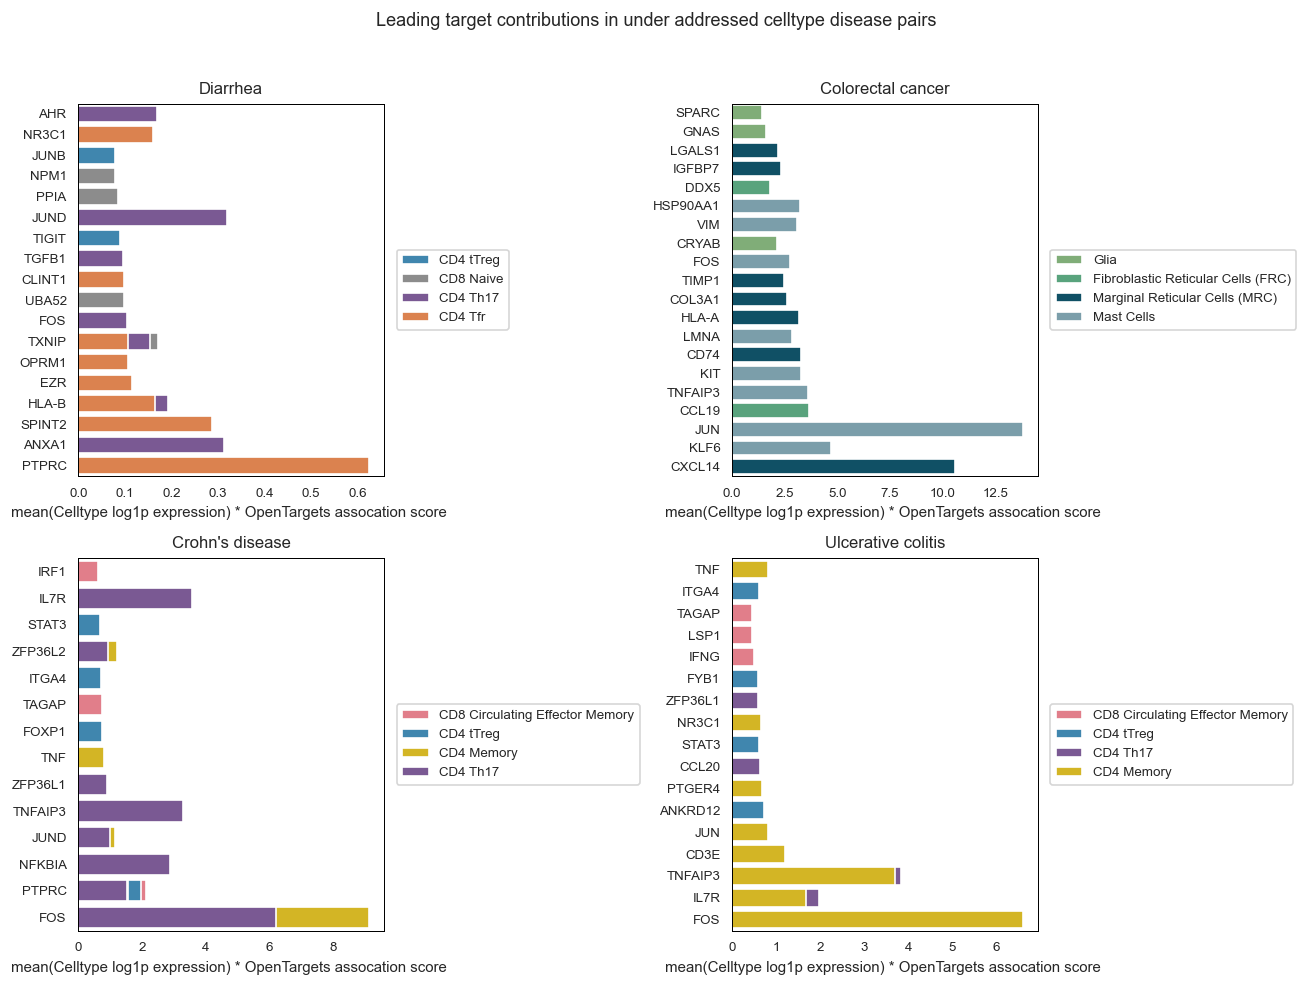

In [231]:
top_n = 8

panelF_top = (
    panelF_df.sort_values("target_contribution", ascending=False)
    .groupby(["disease_label", "cell_type"], as_index=False, group_keys=False)
    .head(top_n)
    .copy()
)

panelF_top["pair_label"] = (
    panelF_top["cell_type"] + " | " + panelF_top["disease_label"].map(DISEASE_DISPLAY)
)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
palette = build_palette(len(DISEASE_ORDER), rotation=5)

all_celltypes = sorted(panelF_top["cell_type"].unique())
celltype_palette = dict(zip(all_celltypes, build_palette(len(all_celltypes), rotation=3)))

for i, disease_label in enumerate(DISEASE_ORDER):
    ax = axes[i]
    sub = panelF_top.loc[panelF_top["disease_label"] == disease_label].copy()

    if sub.empty:
        ax.set_title(DISEASE_DISPLAY[disease_label])
        ax.axis("off")
        continue

    sub = sub.sort_values("target_contribution", ascending=True)

    sns.barplot(
        data=sub,
        y="target_symbol",
        x="target_contribution",
        hue="cell_type",
        dodge=False,
        palette=celltype_palette,
        ax=ax
    )

    ax.set_title(DISEASE_DISPLAY[disease_label])
    ax.set_xlabel("mean(Celltype log1p expression) * OpenTargets assocation score ")
    ax.set_ylabel("")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="")
    style_axes_box(ax)

fig.suptitle("Leading target contributions in under addressed celltype disease pairs", y=1.02)
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_target_contributions_under_addressed_celltype_disease_pairs.png", dpi=400, bbox_inches="tight")

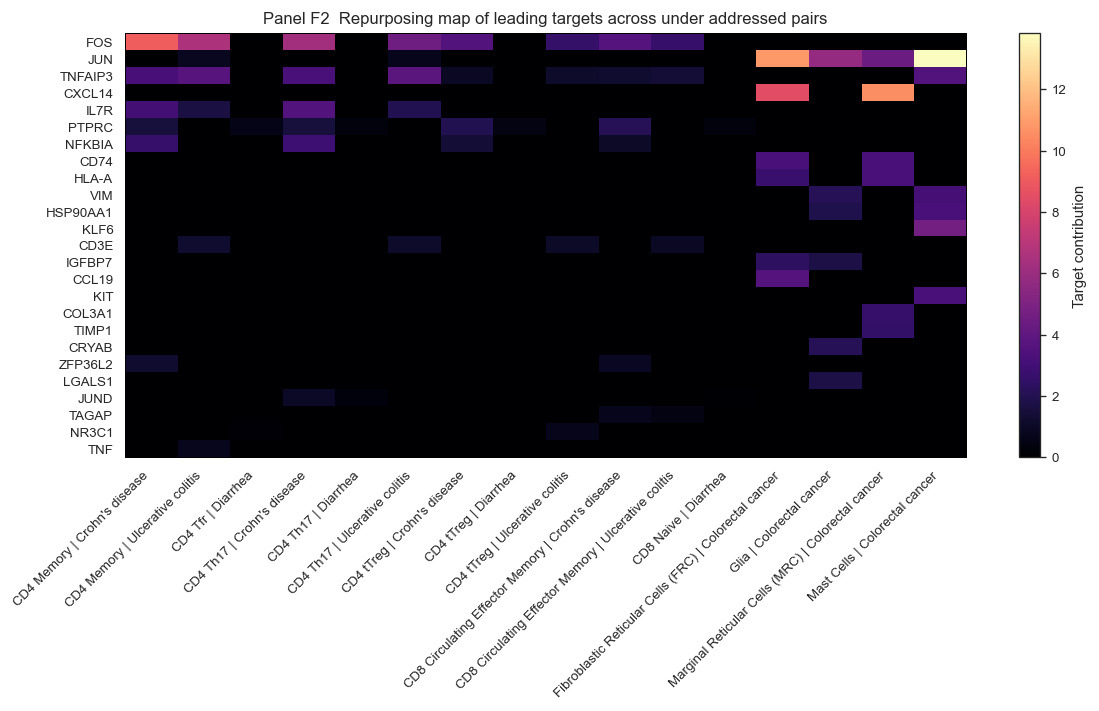

In [232]:
top_per_pair = (
    panelF_df.sort_values("target_contribution", ascending=False)
    .groupby(["disease_label", "cell_type"], as_index=False, group_keys=False)
    .head(6)
    .copy()
)

top_targets = (
    top_per_pair.groupby("target_symbol", as_index=False)
    .agg(total_contribution=("target_contribution", "sum"))
    .sort_values("total_contribution", ascending=False)
    .head(25)["target_symbol"]
    .tolist()
)

heat_df = top_per_pair.loc[top_per_pair["target_symbol"].isin(top_targets)].copy()
heat_df["pair_label"] = (
    heat_df["cell_type"] + " | " + heat_df["disease_label"].map(DISEASE_DISPLAY)
)

heat_mat = heat_df.pivot_table(
    index="target_symbol",
    columns="pair_label",
    values="target_contribution",
    aggfunc="sum",
    fill_value=0
)

heat_mat = heat_mat.loc[heat_mat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(6, 0.22 * heat_mat.shape[0])))

# Y = sch.linkage(data, method='centroid')


im = ax.imshow(heat_mat.values, aspect="auto", cmap="magma")

ax.set_xticks(np.arange(heat_mat.shape[1]))
ax.set_xticklabels(heat_mat.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(heat_mat.shape[0]))
ax.set_yticklabels(heat_mat.index)

ax.set_title("Panel F2  Repurposing map of leading targets across under addressed pairs")
style_axes_box(ax)
fig.colorbar(im, ax=ax, label="Target contribution")
plt.tight_layout()
plt.show()

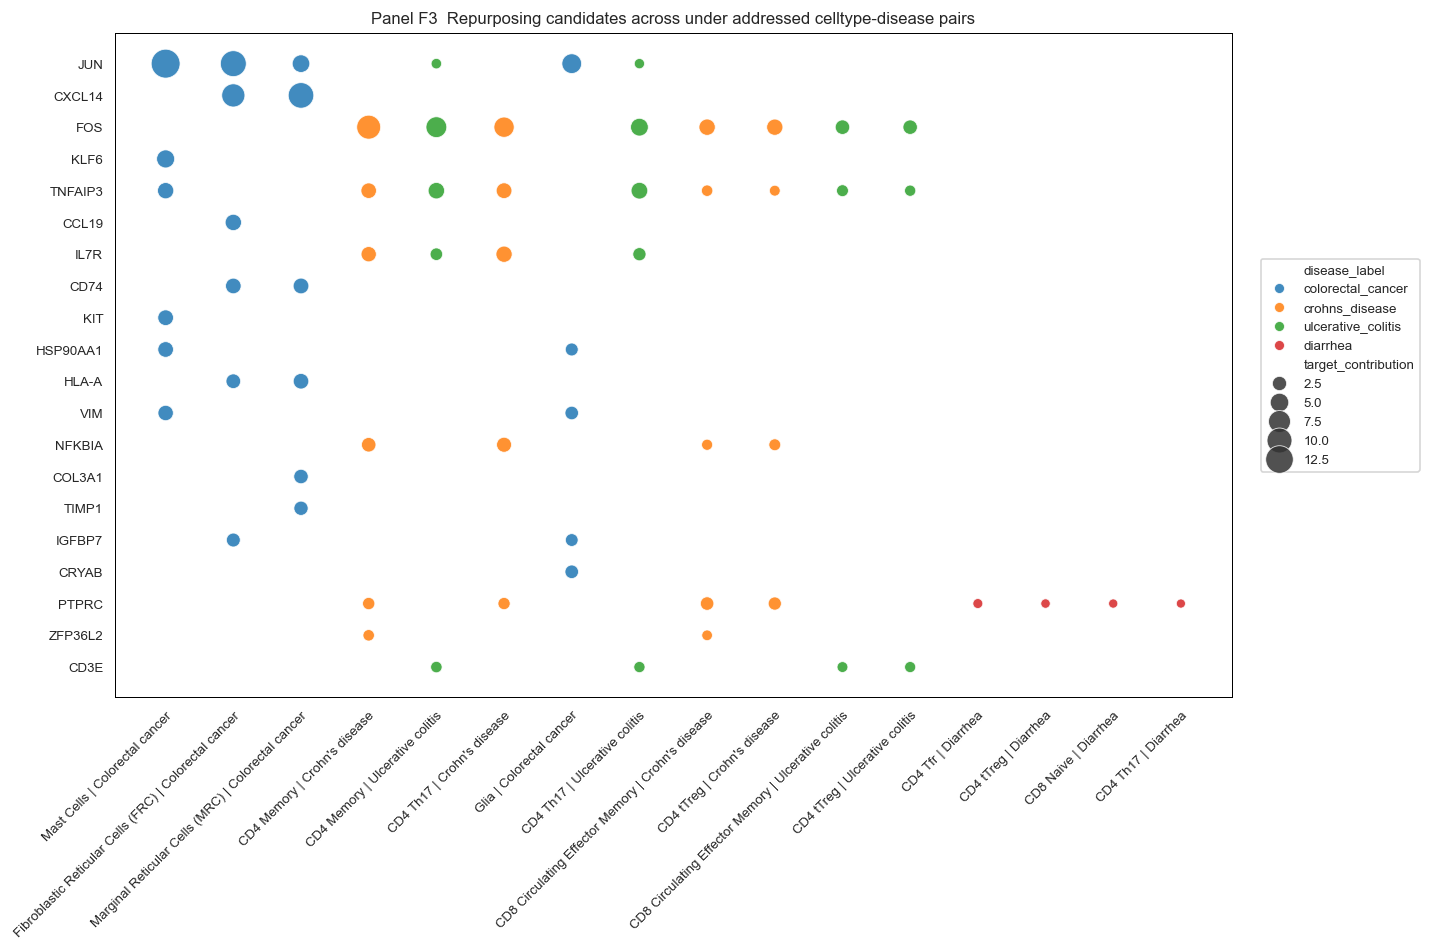

In [233]:
bubble_df = top_per_pair.copy()
bubble_df["pair_label"] = (
    bubble_df["cell_type"] + " | " + bubble_df["disease_label"].map(DISEASE_DISPLAY)
)

top_targets = (
    bubble_df.groupby("target_symbol", as_index=False)
    .agg(total_contribution=("target_contribution", "sum"))
    .sort_values("total_contribution", ascending=False)
    .head(20)["target_symbol"]
    .tolist()
)

bubble_df = bubble_df.loc[bubble_df["target_symbol"].isin(top_targets)].copy()

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=bubble_df,
    x="pair_label",
    y="target_symbol",
    size="target_contribution",
    hue="disease_label",
    sizes=(30, 300),
    alpha=0.85,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Panel F3  Repurposing candidates across under addressed celltype-disease pairs")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
style_axes_box(ax)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

In [234]:
OUT_DIR = Path("/Users/kylekimler/Projects/GCA/github_vignette_output/DALYopportunities")
OUT_DIR.mkdir(exist_ok=True, parents=True)

vuln_by_ct.to_csv(OUT_DIR / "panelA_vulnerability_by_celltype.csv", index=False)
disease_exploredness.to_csv(OUT_DIR / "panelB_disease_exploredness.csv", index=False)
addressability.to_csv(OUT_DIR / "panelC_addressability_summary.csv", index=False)
celltype_summary.to_csv(OUT_DIR / "panelD_panelE_celltype_summary.csv", index=False)
burden.to_csv(OUT_DIR / "panelC_burden_long.csv", index=False)

print("Saved outputs to:", OUT_DIR.resolve())


Saved outputs to: /Users/kylekimler/Projects/GCA/github_vignette_output/DALYopportunities
